# 03 — Latent-space structure analysis

Compares the 2D geometry (PCA and UMAP) of different frozen representations — RGB VAE, grayscale VAE, color-denoising VAE, the non-learned RGB/HSV color baseline, and (if available) the DINOv2 baseline — on the same external test set, colored by tissue class.

This complements the linear-probe numbers in `docs/RESULTS.md` with a qualitative view: *where* do classes overlap in each representation's latent space, not just *how well* a linear classifier separates them.

**Real data**: point `REPRESENTATIONS` below at the `embeddings.csv` / `*_features.csv` files produced by `src/evaluate.py`, `src/extract_color_features.py`, `src/extract_pretrained_embeddings.py` or `src/extract_segmentation_features.py`.

**No trained models yet?** This notebook falls back to the synthetic dataset plus the two classical, non-learned feature extractors already in the project (`src/analysis/color_features.py`, `src/analysis/nuclei_segmentation.py`), so the comparison machinery below can be exercised end to end without training anything first.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parents[0]))

from src.analysis.embedding_projection import (
    compute_2d_projection,
    plot_projection,
)

## Load representations

`REPRESENTATIONS` maps a label to `(csv_path, feature_prefix)`. Only entries whose file exists are used; if none exist, a synthetic fallback is generated below.

In [3]:
REPRESENTATIONS = {
    "rgb_vae": (
        "./outputs/runs/20260716_181630_crc_pilot_vae_beta_1/evaluation/test/embeddings.csv",
        "latent_",
    ),
    "grayscale_vae": (
        "./outputs/runs/20260717_000412_crc_pilot_grayscale_vae_beta_1/evaluation/test/embeddings.csv",
        "latent_",
    ),
    "color_denoising_vae": (
        "./outputs/runs/20260717_014159_crc_pilot_color_denoising_vae_beta_1/evaluation/test/embeddings.csv",
        "latent_",
    ),
    # "rgb_hsv_color_baseline": (
    #     "./outputs/color_features/test_features.csv",
    #     "color_",
    # ),
    "dinov2_vits14": (
        "./outputs/dinov2_vits14/test_embeddings.csv",
        "dinov2_vits14_",
    ),
}

available_representations = {}

for label, (csv_path, feature_prefix) in REPRESENTATIONS.items():
    path = Path(csv_path)
    if path.exists():
        available_representations[label] = (
            pd.read_csv(path),
            feature_prefix,
        )

print(f"Found {len(available_representations)} real representation(s): "
      f"{list(available_representations.keys())}")

Found 4 real representation(s): ['rgb_vae', 'grayscale_vae', 'color_denoising_vae', 'dinov2_vits14']


In [4]:
if not available_representations:
    print(
        "No real embeddings found — generating a synthetic "
        "fallback dataset and extracting the two classical, "
        "non-learned feature sets instead (color statistics "
        "and nuclei segmentation). Train real models and "
        "re-run src/evaluate.py to compare actual VAE latents."
    )

    from src.analysis.color_features import extract_color_feature_frame
    from src.analysis.nuclei_segmentation import (
        NucleiSegmentationConfig,
        extract_nuclei_feature_frame,
    )
    from src.datasets.split import assign_patient_splits
    from src.datasets.synthetic import generate_synthetic_histology_dataset

    synthetic_metadata = generate_synthetic_histology_dataset(
        output_dir="../data/raw/synthetic_patches",
        metadata_path="../data/metadata/synthetic_metadata.csv",
        num_patients=15,
        slides_per_patient=1,
        patches_per_slide=10,
        image_size=64,
        seed=2,
    )
    synthetic_metadata = assign_patient_splits(
        metadata=synthetic_metadata,
        train_fraction=0.6,
        validation_fraction=0.2,
        test_fraction=0.2,
        seed=2,
        stratify_column=None,
    )

    color_frame = extract_color_feature_frame(synthetic_metadata)
    segmentation_frame = extract_nuclei_feature_frame(
        synthetic_metadata,
        config=NucleiSegmentationConfig(sample_size=64),
    )

    available_representations = {
        "synthetic_color_features": (color_frame, "color_"),
        "synthetic_nuclei_segmentation": (segmentation_frame, "segmentation_"),
    }

## PCA comparison

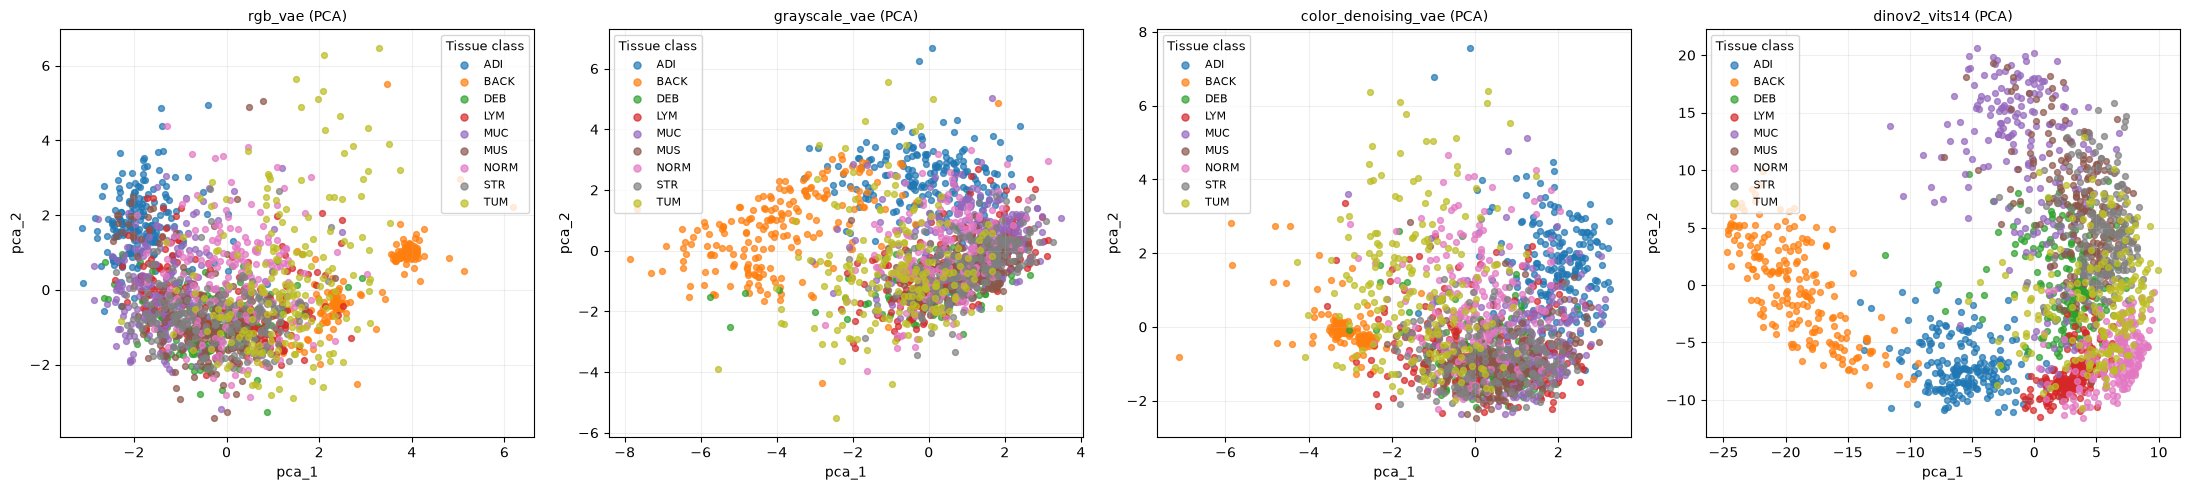

In [5]:
pca_results = {
    label: compute_2d_projection(frame, feature_prefix, method="pca")
    for label, (frame, feature_prefix) in available_representations.items()
}

n_panels = len(pca_results)
fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

for ax, (label, result) in zip(axes, pca_results.items()):
    plot_projection(result, ax=ax, title=f"{label} (PCA)")

plt.tight_layout()

## UMAP comparison

UMAP can reveal non-linear cluster structure that PCA's linear projection misses, at the cost of not having an interpretable "explained variance".

c:\Users\User\Documents\histology_vae_student\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\Documents\histology_vae_student\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\User\Documents\histology_vae_student\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\User\Documents\histology_vae_student\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\User\Documents\histology_vae_student\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by 

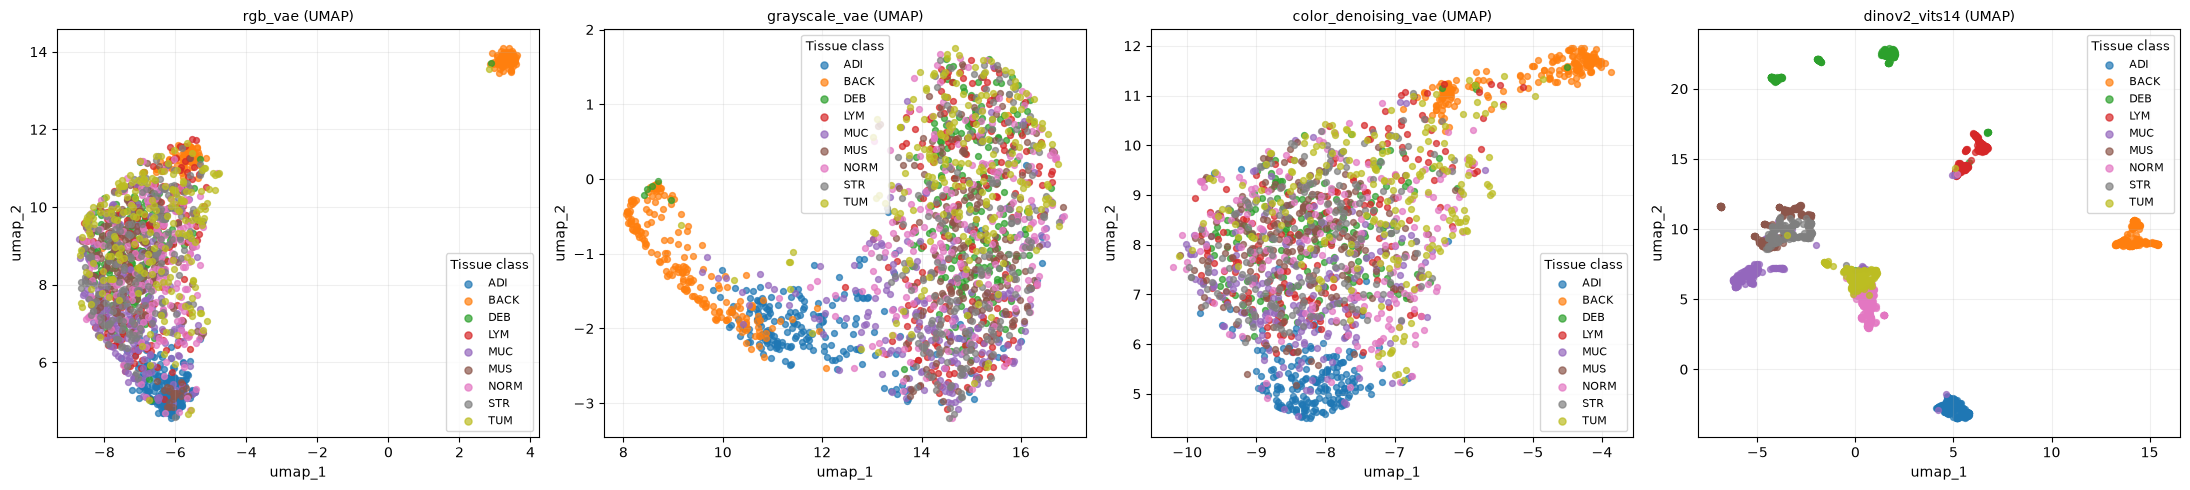

In [6]:
umap_results = {
    label: compute_2d_projection(
        frame, feature_prefix, method="umap", umap_n_neighbors=15
    )
    for label, (frame, feature_prefix) in available_representations.items()
}

fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

for ax, (label, result) in zip(axes, umap_results.items()):
    plot_projection(result, ax=ax, title=f"{label} (UMAP)")

plt.tight_layout()

## Notes

- If the non-learned color baseline shows visually tighter, more separated clusters than the VAE latents, that is a qualitative echo of the quantitative color-shortcut finding in `docs/RESULTS.md` — color alone organizes this dataset better than what the VAE learns to reconstruct.
- Once `src/extract_pretrained_embeddings.py` has been run for a real checkpoint, add its output to `REPRESENTATIONS` above to compare DINOv2 against the VAE variants on the same plot.
- These are 2D projections of higher-dimensional spaces; always read them alongside the linear-probe and retrieval numbers, not instead of them.